In [2]:
# !pip install docplex
# !pip install memory_profiler
# !pip install dwave-system
# !pip install gurobipy
# !pip install yfinance

In [20]:
###############################################################################
# // SPDX-License-Identifier: Apache-2.0
# // Copyright 2024: Amazon Web Services, Inc. - Contributions from JPMC
###############################################################################

import numpy as np
import pandas as pd
from itertools import product
import sys
sys.path.append("../")
from dcmppln.pipeline import Pipeline
from dcmppln.optimizer import GurobiOptimizer
from tests.input_data import InputData
from dcmppln.optimizer import SimulatedAnnealingDwave, NumpyOptimizer
import yfinance as yf
from typing import List
from dcmppln.denoiser import Denoiser, Denoiser_Shrinkage, Denoiser_Bayesian_PCA, Denoiser_PTSCDS, Denoiser_Bootstrap
from dcmppln.utils.preprocess_ticker_data import calculate_returns_correlations

Real market data

In [ ]:
# List of stock markets
markets = {
    "payment_processors": ["V", "MA", "PYPL", "AXP", "DFS", "FI", "GPN", "FIS", "SQ", "ADP"],
    "defense_contractors": ["LMT", "RTX", "NOC", "GD", "BA", "HII", "TXT", "LDOS", "CW", "LHX"],
    "consumer_staples": ["PG", "KO", "PEP", "WMT", "COST", "CL", "MDLZ", "TGT", "SYY"], #"KHC", 
    "cloud_computing": ["MSFT", "AMZN", "GOOGL", "CRM", "ORCL", "IBM", "NOW", "DDOG", "ZS", "PANW"],
    "autonomous_vehicles": ["TSLA", "GM", "F", "GOOGL", "NVDA", "INTC", "MBLY", "APTIV", "TM", "LI"],
    "ecommerce_giants": ["AMZN", "BABA", "SHOP", "WMT", "EBAY", "MELI", "JD", "SE", "PDD", "TGT"],
    "biotech_innovators": ["BIIB", "REGN", "VRTX", "ILMN", "CRSP", "NTLA", "BEAM", "EDIT", "BMRN", "XBI"],
    "metaverse_stocks": ["META", "RBLX", "U", "NVDA", "MSFT", "GOOGL", "DIS", "SONY", "AAPL", "MTTR"],
    "cybersecurity_leaders": ["PANW", "FTNT", "CRWD", "ZS", "OKTA", "CHKP", "MSFT", "NET", "CYBR", "BUG"],
    "semiconductor_giants": ["NVDA", "AMD", "INTC", "TSM", "QCOM", "AVGO", "ASML", "TXN", "MU", "LRCX"],
    "green_energy": ["TSLA", "PLUG", "ENPH", "SEDG", "FSLR", "RUN", "NEE", "BE", "BLDP", "ICLN"],
    "space_exploration": ["SPCE", "RKLB", "BA", "LMT", "NOC", "IRDM", "AJRD", "MAXR", "AVAV", "UFO"],
    "tech_titans": ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",  "TSLA", "QQQ", "VGT", "IGM"],#"META",
    "financial_giants": ["JPM", "BAC", "GS", "WFC", "C", "MS", "SCHW", "V", "MA", "XLF"],
    "retail_consumer": ["WMT", "TGT", "COST", "HD", "LOW", "ULTA", "NKE", "SBUX", "AMZN", "XRT"],
    "healthcare_leaders": ["UNH", "JNJ", "PFE", "MRK",  "LLY", "BMY", "TMO", "ISRG", "XLV"], #"ABBV",
    "energy_utilities": ["XOM", "CVX", "BP", "OXY", "COP", "ENB", "KMI", "NEE", "DUK", "XLE"],
    "industrial_powerhouses": ["CAT", "GE", "HON", "DE", "LMT", "BA", "MMM", "RTX", "EMR", "XLI"],
    "real_estate_reits": ["VNQ", "O", "SPG", "AMT", "CCI", "PSA", "VICI", "PLD", "WELL", "XLRE"],
    "entertainment_media": ["DIS", "NFLX", "CMCSA", "WBD", "PARA", "SPOT", "EA", "ROKU", "FOXA", "XLC"],  # Replaced SONY with EA
    "international_giants": ["BABA", "TSM", "ASML", "NVS", "SAP", "TM", "LVMUY", "RIO", "VALE", "IXUS"],
    "defensive_plays": ["KO", "PG", "JNJ", "MCD", "PEP", "WMT", "XLU", "VYM", "TLT", "VGIT"],
    }


In [9]:
def download_data(stocks: List[str], start_date: str, end_date: str, period_step: int) -> pd.DataFrame:
    stock_data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)["Close"][::period_step]
    return pd.DataFrame(stock_data)

# Define time period for analysis
start_date = "2010-07-01"
end_date = "2020-07-01"
period_step = 5  # Weekly changes

# Combine multiple markets into one big portfolio
markets_for_port=['tech_titans', 'healthcare_leaders', 'consumer_staples', 'semiconductor_giants','financial_giants', 'retail_consumer', 'industrial_powerhouses']
big_portfolio = [w for v in 
        [markets[c] for c in markets_for_port
                              ]
        for w in v
]
dataset = download_data(big_portfolio, start_date, end_date, period_step)

# Compute summary stats for PO
po_data = calculate_returns_correlations(dataset, True)

In [15]:
# Unpack summary stats
raw_returns = po_data.returns
returns = po_data.mean_returns
covariances = po_data.covariances
correlations = po_data.correlations

In [31]:

correlations.shape, covariances.shape, returns.shape

((62, 62), (62, 62), (62,))

For testing purposes, it is simpler to use a default randomly generated dataset

In [32]:
from tests.input_data import InputData

input_data = InputData(path_name='seed_1000_size_90')


correlations,covariances,returns = input_data.data_for_pipeline()

In [33]:

correlations.shape, covariances.shape, returns.shape

((90, 90), (90, 90), (90,))

 # Test Different Denoisers

In [57]:
active_denoisers = True
# RMT Denoiser published by JPM
rmt_denoiser = Denoiser(active=active_denoisers)
# Shrinkage Denoiser
shrinkage_denoiser = Denoiser_Shrinkage(active=active_denoisers)
# Bayesian PCA Denoiser
bayesianpca_denoiser = Denoiser_Bayesian_PCA(active=active_denoisers, data=dataset)
# PTSCDS Denoiser
ptscds_denoiser = Denoiser_PTSCDS(active=active_denoisers)
# Bootstrap Denoiser
bootstrap_denoiser = Denoiser_Bootstrap(active=active_denoisers)

In [58]:
# The function used in the pipeline for these is split_covariance_matrices

# rmt_denoiser, for reference
C_2, denoise_process_time, denoise_time=rmt_denoiser.denoise(correlations)
C_2


array([[ 3.39784994e-01, -3.91630598e-02,  3.23060141e-02, ...,
        -5.18774618e-02,  9.84837812e-02, -1.53439446e-02],
       [-3.91630598e-02,  4.20338714e-02,  1.79681309e-02, ...,
         2.28948697e-02, -1.23795971e-02,  4.10565426e-02],
       [ 3.23060141e-02,  1.79681309e-02,  6.50567203e-01, ...,
        -3.26300536e-02,  1.30100747e-01, -4.48819577e-02],
       ...,
       [-5.18774618e-02,  2.28948697e-02, -3.26300536e-02, ...,
         3.33977755e-02, -2.90098902e-02,  1.90866842e-02],
       [ 9.84837812e-02, -1.23795971e-02,  1.30100747e-01, ...,
        -2.90098902e-02,  2.03780881e-01, -1.96824432e-05],
       [-1.53439446e-02,  4.10565426e-02, -4.48819577e-02, ...,
         1.90866842e-02, -1.96824432e-05,  1.02333079e-01]])

In [59]:
# Shrinkage_denoiser, for reference
C_2, denoise_process_time, denoise_time=shrinkage_denoiser.denoise(correlations)
C_2

array([[ 8.52389482e-03, -7.72392724e-04, -3.69086358e-04, ...,
        -7.66872665e-04,  8.46029284e-04, -6.83366678e-04],
       [-7.72392724e-04,  5.14696404e-03,  3.00770221e-04, ...,
         6.31667108e-04, -5.30126806e-04,  8.59486407e-04],
       [-3.69086358e-04,  3.00770221e-04,  1.01473020e-02, ...,
        -3.86306288e-05, -4.49382530e-04, -1.41045613e-04],
       ...,
       [-7.66872665e-04,  6.31667108e-04, -3.86306288e-05, ...,
         3.91341773e-03, -6.65694482e-04,  2.53105957e-04],
       [ 8.46029284e-04, -5.30126806e-04, -4.49382530e-04, ...,
        -6.65694482e-04,  8.31975022e-03, -9.66022870e-05],
       [-6.83366678e-04,  8.59486407e-04, -1.41045613e-04, ...,
         2.53105957e-04, -9.66022870e-05,  7.05152940e-03]])

In [60]:
# Bayesian PCA, for reference
C_2, denoise_process_time, denoise_time=bayesianpca_denoiser.denoise(correlations)
C_2

,AAPL,MSFT,NVDA,AMZN,GOOGL,TSLA,QQQ,VGT,IGM,UNH,...,CAT,GE,HON,DE,LMT,BA,MMM,RTX,EMR,XLI
AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MSFT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GOOGL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RTX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EMR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# PTSCDS, for reference
C_2, denoise_process_time, denoise_time=ptscds_denoiser.denoise(correlations)
C_2

TypeError: '<' not supported between instances of 'float' and 'NoneType'

In [46]:
# Bootstrap, for reference
C_2, denoise_process_time, denoise_time=bootstrap_denoiser.denoise(correlations)
C_2

TypeError: '<' not supported between instances of 'float' and 'NoneType'

# Pipe Line Test

In [53]:
number_of_runs=10
# 2a Run:
# Initialize dataframe to store results
results_df = pd.DataFrame(columns=["Run", "Distribution", "Optimizer", "Correlations", "Covariances", "Returns", "Score", "Solution"])

for i in range(number_of_runs):
    denoisers = [Denoiser(),
                 Denoiser_Shrinkage(),
                 ]
    # Without denoising
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)
    # With denoising
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
        denoiser = Denoiser(active=True)
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, 'MP', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)
    # With shrinkage
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
        denoiser = Denoiser_Shrinkage(active=True)
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, 'Shrinkage', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)

Objective value with this comm detection algorithm 0.17117381213067556
Communities found at level 1:  1


/tmp/ipykernel_25157/3921501385.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([[i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]],


Objective value with this comm detection algorithm 0.20277768502043925
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.1624847321092575
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.16629634791391934
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.1668443421815856
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.18254681167283002
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.18098853996198697
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.19373813956408087
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.19342033820960008
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.1887615990865836
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.19148420151001

In [54]:
# Display the results dataframe
results_df.head()

,Run,Distribution,Optimizer,Correlations,Covariances,Returns,Score,Solution
0,0,None,Dwave,"[[1.0, 0.2731195274435611, 0.03104089575164402...","[[0.0004381310776740527, 0.000155697106160498,...","[0.0014147932895997534, 0.0001292070281345941,...",0.171174,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, ..."
1,0,MP,Dwave,"[[1.0, 0.2731195274435611, 0.03104089575164402...","[[0.0004381310776740527, 0.000155697106160498,...","[0.0014147932895997534, 0.0001292070281345941,...",0.202778,"[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, ..."
2,0,Shrinkage,Dwave,"[[1.0, 0.2731195274435611, 0.03104089575164402...","[[0.0004381310776740527, 0.000155697106160498,...","[0.0014147932895997534, 0.0001292070281345941,...",0.162485,"[0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, ..."
3,1,None,Dwave,"[[1.0, 0.2731195274435611, 0.03104089575164402...","[[0.0004381310776740527, 0.000155697106160498,...","[0.0014147932895997534, 0.0001292070281345941,...",0.166296,"[1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, ..."
4,1,MP,Dwave,"[[1.0, 0.2731195274435611, 0.03104089575164402...","[[0.0004381310776740527, 0.000155697106160498,...","[0.0014147932895997534, 0.0001292070281345941,...",0.166844,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."


In [55]:
results_df.groupby('Distribution')['Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Distribution,,,,,,,,
MP,10.0,0.188361,0.009713,0.166844,0.184658,0.190797,0.193175,0.202778
None,10.0,0.181165,0.011157,0.166296,0.173034,0.180502,0.188199,0.200796
Shrinkage,10.0,0.182328,0.011187,0.162485,0.174406,0.182894,0.192149,0.194495


Over 50 runs
- Shrinkage has a slightly lower average score than MP, but still higher than using no denoising (lower is better)
- All denoisers occasionally produce bad solutions with this data (ther 0 score solutions, these actually have no assets at all). 

In [116]:
range(i*10, (i+1)*10)

range(60, 70)

In [154]:
solution=[int(v) for v in results_df.iloc[2]['Solution']]
df_solution = pd.DataFrame()
df_solution['asset']=returns.columns.values
df_solution['pick'] = solution


In [158]:
df_solution['Market'] = df_solution['asset'].apply(lambda x:
                                                   [key for key,val in markets.items() if x in val][0])

In [160]:
print(df_solution)

    asset  pick                  Market
0    AAPL     1             tech_titans
1    MSFT     0             tech_titans
2    NVDA     0    semiconductor_giants
3    AMZN     0             tech_titans
4   GOOGL     0             tech_titans
..    ...   ...                     ...
60     BA     0  industrial_powerhouses
61    MMM     1  industrial_powerhouses
62    RTX     0  industrial_powerhouses
63    EMR     1  industrial_powerhouses
64    XLI     1  industrial_powerhouses

[65 rows x 3 columns]


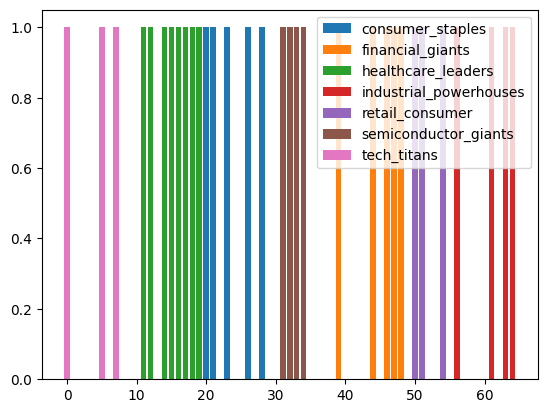

In [164]:
import matplotlib.pyplot as plt
for market,subdf in df_solution.groupby('Market'):
    plt.bar(x=subdf.index, height=subdf.pick, label=market)
plt.legend(loc='best')